In [1]:
# ============================================================
# 1. LOADING AND MERGING THE ALARM SOURCES
# ============================================================
# Source A: the SCADA log already exported to CSV.
import pandas as pd

logs= pd.read_csv('../data/logs_msc10_synthetic.csv')
logs.head()

,state,log_time,message,send_time
0,D,2026-01-01 03:33:04,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,2026-01-01 03:34:12
1,D,2026-01-01 04:25:14,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,2026-01-01 05:05:37
2,D,2026-01-01 04:46:58,\BLIDA MSC 10\ Salle Switch Temperature Haute,2026-01-01 05:14:16
3,Acquittement - Systeme,2026-01-01 04:47:07,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,2026-01-01 05:33:24
4,Acquittement - Systeme,2026-01-01 06:38:57,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,2026-01-01 07:16:02


In [2]:
# Source B: the 2022 SCADA alarm workbook, restricted to the MSC 10 site
# (the file covers several sites, we only need this one).
df_logs = pd.read_excel('../data/ALARMES SCADA 2022_synthetic.xlsx')
df_msc10 = df_logs[df_logs["message"].str.contains("MSC 10", case=False, na=False)]

df_msc10 = df_msc10.reset_index(drop=True)

print(df_msc10.head())

               Counter                   state                    time  \
0  7062044201726252032                       D  01/01/2022 12:03:15 AM   
1  7062044201726251008                       A  01/01/2022 12:10:58 AM   
2  7062044201726251008                       D  01/01/2022 12:23:18 AM   
3  7062044201726251008                       D  01/01/2022 12:36:06 AM   
4  7062044201726251008  Acquittement - Systeme  01/01/2022 12:49:01 AM   

                                            message               send Time  \
0  \BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK  01/02/2022 09:21:14 AM   
1  \BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK  01/01/2022 05:50:56 PM   
2           \BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM  01/02/2022 12:56:08 AM   
3           \BLIDA MSC 10\ UPS UNIT 2 GENERAL ALARM  01/02/2022 04:11:37 AM   
4                  \BLIDA MSC 10\ UPS GENERAL ALARM  01/01/2022 03:02:02 AM   

                           NNMi  \
0  Alger centre: 172.16.12.10,    
1  Dar el 

In [3]:
# Align both sources on the same four columns before stacking them:
# the Excel export names its columns differently from the CSV.
df_msc10.to_csv('../data/msc10_from_alarmes_synthetic.csv', index=False)
df_msc10_renamed = df_msc10.rename(columns={
    'time': 'log_time',
    'send Time': 'send_time'
})[['state', 'log_time', 'message', 'send_time']]

df_csv_aligned = logs[['state', 'log_time', 'message', 'send_time']]
df_combined = pd.concat([df_csv_aligned, df_msc10_renamed], ignore_index=True)

print(df_combined.info())
print(df_combined.head())

<class 'pandas.DataFrame'>
RangeIndex: 27067 entries, 0 to 27066
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   state      27067 non-null  str  
 1   log_time   27067 non-null  str  
 2   message    27067 non-null  str  
 3   send_time  27067 non-null  str  
dtypes: str(4)
memory usage: 846.0 KB
None
                    state             log_time  \
0                       D  2026-01-01 03:33:04   
1                       D  2026-01-01 04:25:14   
2                       D  2026-01-01 04:46:58   
3  Acquittement - Systeme  2026-01-01 04:47:07   
4  Acquittement - Systeme  2026-01-01 06:38:57   

                                             message            send_time  
0         \BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY  2026-01-01 03:34:12  
1            \BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY  2026-01-01 05:05:37  
2     \BLIDA MSC 10\  Salle Switch Temperature Haute  2026-01-01 05:14:16  
3            \BLIDA MSC 10\

In [4]:
# Parse both time columns; unparsable values become NaT and are counted,
# then drop alarms duplicated on (timestamp, message).
df_combined['log_time'] = pd.to_datetime(df_combined['log_time'], errors='coerce')
df_combined['send_time'] = pd.to_datetime(df_combined['send_time'], errors='coerce')

print(df_combined['log_time'].isna().sum())
print(df_combined['send_time'].isna().sum())

dupes = df_combined.duplicated(subset=['log_time', 'message']).sum()
print(dupes)
df_combined = df_combined.drop_duplicates(subset=['log_time', 'message']).reset_index(drop=True)

24817


24817
24810


In [5]:
# Sort chronologically and save the merged log for reuse.
df_combined = df_combined.sort_values('log_time').reset_index(drop=True)
df_combined.to_csv('../data/msc10_combined_synthetic.csv', index=False)

In [6]:
# ============================================================
# 2. CATEGORISING ALARMS BY SUBSYSTEM
# ============================================================
# Keyword rules map each free-text message to the equipment family it
# belongs to: UPS, air conditioning (CLIM), power (ENERGY), or OTHER.
# str()/notna guard: some messages are missing and would break .upper().
import numpy as np

def categorize(message):
    msg = str(message).upper() if pd.notna(message) else ""
    if any(k in msg for k in ["UPS", "SOCOMEC", "BATTERY"]):
        return "UPS"
    elif any(k in msg for k in ["CLIM", "STULZ", "LIEBERT", "TEMPERATURE"]):
        return "CLIM"
    elif any(k in msg for k in ["TENSION", "GROUPE ELECTROGENE", "ELECTROGENE"]):
        return "ENERGY"
    return "OTHER"

df_combined['category'] = df_combined['message'].apply(categorize)
print(df_combined['category'].value_counts())


category
UPS       1316
ENERGY     633
CLIM       308
Name: count, dtype: int64


In [7]:
# Check what fell into OTHER (i.e. what the rules above missed), then build
# a day x category count table.
print(df_combined[df_combined['category'] == 'OTHER']['message'].value_counts())
df_combined['date'] = df_combined['log_time'].dt.date
category_timeline = df_combined.groupby(['date', 'category']).size().unstack(fill_value=0)
print(category_timeline.head())

Series([], Name: count, dtype: int64)
category    CLIM  ENERGY  UPS
date                         
2026-01-01     3       3   17
2026-01-02     3       4    8
2026-01-03     5       0   16
2026-01-04     1       3    9
2026-01-05     5       3   10


In [8]:
# ============================================================
# 3. FREQUENCY-BASED ANOMALY DETECTION (DAILY COUNTS)
# ============================================================
# frequency based anomaly detection
# my daily counts only has rows where at least one alarm fired that day. i will reindex to include every calendar day (with 0s) between your min and max date
df_combined = df_combined.set_index('log_time')
daily_counts = df_combined.groupby([pd.Grouper(freq='D'), 'category']).size().unstack(fill_value=0)
full_range = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D')
daily_counts = daily_counts.reindex(full_range, fill_value=0)
daily_counts.index.name = 'log_time'
print(daily_counts.shape)
print(daily_counts.sum())

(120, 3)


category
CLIM       308
ENERGY     633
UPS       1309
dtype: int64


In [9]:
# Baseline 1: classic rolling z-score. A day is unusual if its count is far
# from the mean of the surrounding 7-day window.
# Rolling mean/std per category (using a 7-day rolling window)
rolling_mean = daily_counts.rolling(window=7, min_periods=3).mean()
rolling_std = daily_counts.rolling(window=7, min_periods=3).std()
z_scores = (daily_counts - rolling_mean) / rolling_std
z_scores = z_scores.replace([np.inf, -np.inf], np.nan)

print(z_scores.tail(10))
# UPS uses the statistical score; CLIM and ENERGY are so rare that a
# simple absolute count threshold is more meaningful than a z-score.
ups_anomalies = daily_counts[z_scores['UPS'].abs() > 2.5]
clim_anomalies = daily_counts[daily_counts['CLIM'] > 2]
energy_anomalies = daily_counts[daily_counts['ENERGY'] > 3]

print("UPS anomalies:")
print(ups_anomalies)
print("\nCLIM anomalies:")
print(clim_anomalies)
print("\nENERGY anomalies:")
print(energy_anomalies)

category        CLIM    ENERGY       UPS
log_time                                
2026-04-21  0.585540  0.977107  1.706247
2026-04-22  0.377964  0.750939  0.000000
2026-04-23  1.966687  1.234994 -0.127573
2026-04-24 -0.707107  1.022397 -1.596246
2026-04-25  0.000000 -1.610235  0.149452
2026-04-26 -0.106199  1.388730  0.903381
2026-04-27 -0.849591 -0.818923 -0.276026
2026-04-28  1.039402 -0.968665 -0.044137
2026-04-29 -0.801784 -0.114395  0.519129
2026-04-30  1.692655 -0.686368  0.425243
UPS anomalies:
Empty DataFrame
Columns: [CLIM, ENERGY, UPS]
Index: []

CLIM anomalies:
category    CLIM  ENERGY  UPS
log_time                     
2026-01-01     3       3   17
2026-01-02     3       4    8
2026-01-03     5       0   16
2026-01-05     5       3   10
2026-01-08     3       6    4
2026-01-09     3       2    9
2026-01-10     4       3    5
2026-01-11     4       7   13
2026-01-15     3       2   17
2026-01-17     5       4   16
2026-01-22     3       4   15
2026-01-23     3       5    7
2

In [10]:
# Problem with the mean/std z-score: a spike inflates the very baseline used
# to judge it, so it hides itself. Median + MAD is robust to that.
#the past the anomalies themselves distort the baseline used to detect them.
def rolling_mad_zscore(series, window=7, min_periods=3):
    rolling_median = series.rolling(window, min_periods=min_periods).median()
    rolling_mad = series.rolling(window, min_periods=min_periods).apply(
        lambda x: np.median(np.abs(x - np.median(x))), raw=True
    )
    z = 0.6745 * (series - rolling_median) / rolling_mad
    return z.replace([np.inf, -np.inf], np.nan)

z_ups_robust = rolling_mad_zscore(daily_counts['UPS'])
print(z_ups_robust.sort_values(ascending=False).head(10))

log_time
2026-03-28    5.39600
2026-03-20    4.72150
2026-02-06    3.37250
2026-03-30    3.37250
2026-04-21    2.69800
2026-04-26    2.69800
2026-01-29    2.36075
2026-03-08    2.02350
2026-03-18    2.02350
2026-02-07    1.68625
Name: UPS, dtype: float64


In [11]:
# Still not enough: the current day is part of its own rolling window.
# shift(1) makes the baseline strictly historical.
def rolling_mad_zscore_excl_current(series, window=7, min_periods=3):
    rolling_median = series.shift(1).rolling(window, min_periods=min_periods).median()
    rolling_mad = series.shift(1).rolling(window, min_periods=min_periods).apply(
        lambda x: np.median(np.abs(x - np.median(x))), raw=True
    )
    z = 0.6745 * (series - rolling_median) / rolling_mad
    return z.replace([np.inf, -np.inf], np.nan)

z_ups_robust = rolling_mad_zscore_excl_current(daily_counts['UPS'])
print(z_ups_robust.sort_values(ascending=False).head(10))

log_time
2026-03-30    7.41950
2026-03-28    5.39600
2026-03-20    5.39600
2026-02-06    3.37250
2026-02-08    2.69800
2026-04-21    2.69800
2026-01-11    2.69800
2026-04-26    2.69800
2026-01-29    2.36075
2026-03-21    2.02350
Name: UPS, dtype: float64


In [12]:
# Final version. On a quiet site the MAD is often exactly 0, which makes the
# score explode to infinity. This version handles the three cases separately.
def rolling_mad_zscore_v3(series, window=7, min_periods=3):
    rolling_median = series.shift(1).rolling(window, min_periods=min_periods).median()
    rolling_mad = series.shift(1).rolling(window, min_periods=min_periods).apply(
        lambda x: np.median(np.abs(x - np.median(x))), raw=True
    )

    diff = series - rolling_median
    z = pd.Series(np.nan, index=series.index)

    # Normal case: MAD > 0
    valid_mad = rolling_mad > 0
    z[valid_mad] = 0.6745 * diff[valid_mad] / rolling_mad[valid_mad]

    # MAD == 0 but real deviation: scale score by deviation size itself,
    # using a global reference scale so magnitudes stay comparable
    global_scale = series[series > 0].median()  # typical nonzero alarm count, as a reference unit
    zero_mad_dev = (rolling_mad == 0) & (diff != 0)
    z[zero_mad_dev] = diff[zero_mad_dev] / global_scale  # bigger spikes -> bigger score, ranked properly

    # MAD == 0 and no deviation: truly flat, not anomalous
    z[(rolling_mad == 0) & (diff == 0)] = 0

    return z

z_ups_robust = rolling_mad_zscore_v3(daily_counts['UPS'])
print(z_ups_robust.sort_values(ascending=False).head(10))

log_time
2026-03-30    7.41950
2026-03-28    5.39600
2026-03-20    5.39600
2026-02-06    3.37250
2026-02-08    2.69800
2026-04-21    2.69800
2026-01-11    2.69800
2026-04-26    2.69800
2026-01-29    2.36075
2026-03-21    2.02350
dtype: float64


In [13]:
# ============================================================
# 4. ISOLATION FOREST ON DAILY COUNTS
# ============================================================
# Multivariate alternative: instead of scoring each category on its own,
# let the model isolate days whose (CLIM, ENERGY, UPS) combination is rare.
# contamination=0.1 assumes roughly 10% of days are unusual.
from sklearn.ensemble import IsolationForest
X = daily_counts[['CLIM', 'ENERGY', 'UPS']].values

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,   
    random_state=42
)

iso_forest.fit(X)
daily_counts['iso_score'] = iso_forest.decision_function(X)
daily_counts['iso_anomaly'] = iso_forest.predict(X)  

print(daily_counts.sort_values('iso_score').head(15))

category    CLIM  ENERGY  UPS  iso_score  iso_anomaly
log_time                                             
2026-04-13     9       4   15  -0.108797           -1
2026-03-30     7       4   19  -0.096369           -1
2026-02-12     0       1    4  -0.081151           -1
2026-02-06     0       3   20  -0.069469           -1
2026-01-03     5       0   16  -0.066173           -1
2026-01-27     0       5    3  -0.064080           -1
2026-02-23     5      11   11  -0.053879           -1
2026-01-26     1       0    7  -0.051525           -1
2026-03-04     7       5    8  -0.049160           -1
2026-02-11     2      11    6  -0.034484           -1
2026-04-26     2      10   15  -0.008484           -1
2026-02-08     0       5   18  -0.004114           -1
2026-03-02     3      11    9   0.000457            1
2026-02-15     4       2    5   0.003130            1
2026-01-30     3      11   12   0.012178            1


In [14]:
# Delay since the previous occurrence of the same message (used later for
# flapping detection).
#rapid disappearance anomalies
df_combined['time_since_last'] = df_combined.groupby('message')['send_time'].diff().dt.total_seconds()

In [15]:
# Second pass: give the forest temporal context (3- and 7-day rolling means
# plus the day-on-day change), not just the raw counts of the day itself.
# Build richer features per day
features = daily_counts[['CLIM', 'ENERGY', 'UPS']].copy()
for col in ['CLIM', 'ENERGY', 'UPS']:
    features[f'{col}_roll3'] = daily_counts[col].rolling(3, min_periods=1).mean()
    features[f'{col}_roll7'] = daily_counts[col].rolling(7, min_periods=1).mean()
    features[f'{col}_diff'] = daily_counts[col].diff().fillna(0)

X = features.values

iso_forest_v2 = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_forest_v2.fit(X)

daily_counts['iso_score_v2'] = iso_forest_v2.decision_function(X)
daily_counts['iso_anomaly_v2'] = iso_forest_v2.predict(X)

print(daily_counts.sort_values('iso_score_v2').head(15))

category    CLIM  ENERGY  UPS  iso_score  iso_anomaly  iso_score_v2  \
log_time                                                              
2026-02-12     0       1    4  -0.081151           -1     -0.056223   
2026-04-13     9       4   15  -0.108797           -1     -0.055207   
2026-01-03     5       0   16  -0.066173           -1     -0.054332   
2026-04-14     2       1   14   0.030986            1     -0.053451   
2026-03-30     7       4   19  -0.096369           -1     -0.043981   
2026-01-27     0       5    3  -0.064080           -1     -0.029853   
2026-01-01     3       3   17   0.085379            1     -0.022622   
2026-02-06     0       3   20  -0.069469           -1     -0.019533   
2026-03-09     1       8    4   0.035847            1     -0.018059   
2026-02-08     0       5   18  -0.004114           -1     -0.014052   
2026-01-28     0       6   10   0.060828            1     -0.011470   
2026-01-05     5       3   10   0.074515            1     -0.002074   
2026-0

In [16]:
# Consecutive flagged days belong to the same operational incident:
# number the runs and summarise each one.
daily_counts['is_anomaly'] = daily_counts['iso_anomaly_v2'] == -1

daily_counts['incident_id'] = (
    daily_counts['is_anomaly'] != daily_counts['is_anomaly'].shift()
).cumsum()

incidents = (
    daily_counts[daily_counts['is_anomaly']]
    .groupby('incident_id')
    .agg(start=('is_anomaly', lambda x: x.index.min()),
         end=('is_anomaly', lambda x: x.index.max()),
         days=('is_anomaly', 'size'),
         max_UPS=('UPS', 'max'),
         total_UPS=('UPS', 'sum'))
)
print(incidents)

                 start        end  days  max_UPS  total_UPS
incident_id                                                
1           2026-01-01 2026-01-01     1       17         17
3           2026-01-03 2026-01-03     1       16         16
5           2026-01-05 2026-01-05     1       10         10
7           2026-01-27 2026-01-28     2       10         13
9           2026-02-06 2026-02-06     1       20         20
11          2026-02-08 2026-02-08     1       18         18
13          2026-02-12 2026-02-12     1        4          4
15          2026-03-09 2026-03-09     1        4          4
17          2026-03-30 2026-03-30     1       19         19
19          2026-04-13 2026-04-14     2       15         29


In [17]:
# Look at the score distribution to pick a manual cut-off instead of relying
# on the contamination parameter.
print(daily_counts['iso_score_v2'].describe())
print(daily_counts['iso_score_v2'].sort_values().head(20))

count    120.000000
mean       0.053336
std        0.040454
min       -0.056223
25%        0.032788
50%        0.062257
75%        0.082930
max        0.114464
Name: iso_score_v2, dtype: float64
log_time
2026-02-12   -0.056223
2026-04-13   -0.055207
2026-01-03   -0.054332
2026-04-14   -0.053451
2026-03-30   -0.043981
2026-01-27   -0.029853
2026-01-01   -0.022622
2026-02-06   -0.019533
2026-03-09   -0.018059
2026-02-08   -0.014052
2026-01-28   -0.011470
2026-01-05   -0.002074
2026-01-26    0.000230
2026-02-01    0.004251
2026-03-31    0.005519
2026-01-17    0.006473
2026-04-17    0.007848
2026-04-04    0.009398
2026-01-18    0.012023
2026-04-24    0.012201
Name: iso_score_v2, dtype: float64


In [18]:
# Same grouping as above, but tolerating a 2-day quiet gap inside an incident
# so a single calm day does not split one event into two.
threshold = 0.02  # placeholder - we'll set this after seeing the describe() output above

daily_counts['is_anomaly'] = daily_counts['iso_score_v2'] < threshold

gap_tolerance = 2
anomaly_dates = daily_counts[daily_counts['is_anomaly']].index
merged_id = 0
incident_ids = pd.Series(index=daily_counts.index, dtype='float')
last_date = None

for date in daily_counts.index:
    if daily_counts.loc[date, 'is_anomaly']:
        if last_date is None or (date - last_date).days > gap_tolerance:
            merged_id += 1
        incident_ids[date] = merged_id
        last_date = date

daily_counts['incident_id'] = incident_ids

incidents = (
    daily_counts.dropna(subset=['incident_id'])
    .groupby('incident_id')
    .agg(start=('UPS', lambda x: x.index.min()),
         end=('UPS', lambda x: x.index.max()),
         days=('UPS', 'size'),
         max_UPS=('UPS', 'max'),
         total_UPS=('UPS', 'sum'))
)
print(incidents)

                 start        end  days  max_UPS  total_UPS
incident_id                                                
1.0         2026-01-01 2026-01-05     4       17         52
2.0         2026-01-17 2026-01-18     2       16         27
3.0         2026-01-26 2026-02-01     5       12         37
4.0         2026-02-06 2026-02-08     2       20         38
5.0         2026-02-12 2026-02-12     1        4          4
6.0         2026-03-04 2026-03-04     1        8          8
7.0         2026-03-08 2026-03-09     2       12         16
8.0         2026-03-30 2026-03-31     2       19         29
9.0         2026-04-04 2026-04-04     1       12         12
10.0        2026-04-13 2026-04-17     4       15         49
11.0        2026-04-24 2026-04-24     1        4          4


In [19]:
# ============================================================
# 5. ADDING THE UPS INTERNAL EVENT LOG
# ============================================================
# The UPS export has its own format, so it is reshaped into the same four
# columns (state / log_time / message / send_time) as the SCADA log:
#  - state   : 'D' when the text says the condition was restored, else 'A'
#  - message : same '\BLIDA MSC 10\ UPS ...' convention as the SCADA log,
#              with the ' has been restored' suffix stripped
#  - log_time: parsed timestamp; unparsable rows are dropped rather than kept
import pandas as pd

df_ups_new = pd.read_csv('../data/ups_clean_synthetic.csv')

description = df_ups_new['description'].fillna('').astype(str)
df_ups_new['state'] = np.where(
    description.str.contains('restored', case=False, na=False),
    'D',
    'A'
)

df_ups_new['message'] = (
    r'\BLIDA MSC 10\ UPS '
    + description.str.replace(' has been restored', '', case=False, regex=False).str.upper()
)

df_ups_new['log_time'] = pd.to_datetime(df_ups_new['ts'], errors='coerce')
df_ups_new['send_time'] = df_ups_new['log_time']

df_ups_new_aligned = (
    df_ups_new[['state', 'log_time', 'message', 'send_time']]
    .dropna(subset=['log_time'])
)

print(df_ups_new_aligned.head(10))
print(df_ups_new_aligned['state'].value_counts())


  state            log_time                                           message  \
0     A 2026-02-10 00:53:25                  \BLIDA MSC 10\ UPS GENERAL ALARM   
1     D 2026-02-10 05:09:16           \BLIDA MSC 10\ UPS PHASE ROTATION FAULT   
2     A 2026-02-10 06:16:13                  \BLIDA MSC 10\ UPS GENERAL ALARM   
3     A 2026-02-10 11:34:36                  \BLIDA MSC 10\ UPS GENERAL ALARM   
4     D 2026-02-10 11:57:37  \BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK   
5     A 2026-02-10 12:33:35       \BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM   
6     A 2026-02-10 19:56:19                  \BLIDA MSC 10\ UPS GENERAL ALARM   
7     D 2026-02-10 21:39:13       \BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM   
8     D 2026-02-11 03:26:22           \BLIDA MSC 10\ UPS OPERATING ON BATTERY   
9     D 2026-02-11 04:29:39       \BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM   

            send_time  
0 2026-02-10 00:53:25  
1 2026-02-10 05:09:16  
2 2026-02-10 06:16:13  
3 2026-02-10

In [20]:
# Merge the UPS events into the combined log.
# log_time may be either a column or the index depending on which cells were
# run before, so it is normalised first; then timestamps are re-parsed,
# incomplete rows dropped, duplicates removed and everything re-sorted.
if 'log_time' not in df_combined.columns:
    df_combined = df_combined.reset_index()

df_combined = pd.concat(
    [df_combined, df_ups_new_aligned],
    ignore_index=True,
    sort=False
)

df_combined['log_time'] = pd.to_datetime(df_combined['log_time'], errors='coerce')
df_combined['send_time'] = pd.to_datetime(df_combined['send_time'], errors='coerce')
df_combined = df_combined.dropna(subset=['log_time', 'message'])

dupes = df_combined.duplicated(subset=['log_time', 'message']).sum()
print("Duplicates found:", dupes)

df_combined = (
    df_combined
    .drop_duplicates(subset=['log_time', 'message'])
    .sort_values('log_time')
    .reset_index(drop=True)
)

print(df_combined.info())
print(df_combined['log_time'].min(), "to", df_combined['log_time'].max())


Duplicates found: 0


<class 'pandas.DataFrame'>
RangeIndex: 3274 entries, 0 to 3273
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   log_time         3274 non-null   datetime64[us]
 1   state            3274 non-null   str           
 2   message          3274 non-null   str           
 3   send_time        3274 non-null   datetime64[us]
 4   category         2250 non-null   str           
 5   date             2250 non-null   object        
 6   time_since_last  2243 non-null   float64       
dtypes: datetime64[us](2), float64(1), object(1), str(3)
memory usage: 179.2+ KB
None
2026-01-01 03:33:04 to 2026-05-09 21:13:21


In [21]:
# Re-apply the category rules now that UPS messages are included, and save.
df_combined['category'] = df_combined['message'].apply(categorize)
print(df_combined['category'].value_counts())
print(df_combined[df_combined['category'] == 'OTHER']['message'].value_counts())
df_combined.to_csv('../data/msc10_combined_ups_synthetic.csv', index=False)

category
UPS       2333
ENERGY     633
CLIM       308
Name: count, dtype: int64


Series([], Name: count, dtype: int64)


In [22]:
# Rebuild the daily count matrix on the enriched log.
df_combined_indexed = df_combined.set_index('log_time')
daily_counts = df_combined_indexed.groupby([pd.Grouper(freq='D'), 'category']).size().unstack(fill_value=0)

full_range = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D')
daily_counts = daily_counts.reindex(full_range, fill_value=0)
daily_counts.index.name = 'log_time'

print(daily_counts.shape)
print(daily_counts.sum())

(129, 3)
category
CLIM       308
ENERGY     633
UPS       2333
dtype: int64


In [23]:
# Re-run the Isolation Forest with the same feature recipe as before,
# this time on the enriched counts.
from sklearn.ensemble import IsolationForest

features = daily_counts[['CLIM', 'ENERGY', 'UPS']].copy()

for col in ['CLIM', 'ENERGY', 'UPS']:
    features[f'{col}_roll3'] = daily_counts[col].rolling(3, min_periods=1).mean()
    features[f'{col}_roll7'] = daily_counts[col].rolling(7, min_periods=1).mean()
    features[f'{col}_diff'] = daily_counts[col].diff().fillna(0)

X = features.values

iso_forest = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_forest.fit(X)

daily_counts['iso_score'] = iso_forest.decision_function(X)
daily_counts['iso_anomaly'] = iso_forest.predict(X)

print(daily_counts['iso_score'].describe())
print(daily_counts.sort_values('iso_score').head(20))

count    129.000000
mean       0.065171
std        0.045069
min       -0.044663
25%        0.037617
50%        0.074059
75%        0.101607
max        0.134549
Name: iso_score, dtype: float64
category    CLIM  ENERGY  UPS  iso_score  iso_anomaly
log_time                                             
2026-04-14     2       1   21  -0.044663           -1
2026-05-01     0       0   10  -0.042438           -1
2026-01-03     5       0   16  -0.035587           -1
2026-04-13     9       4   26  -0.034305           -1
2026-05-03     0       0    3  -0.032206           -1
2026-01-27     0       5    3  -0.025614           -1
2026-05-09     0       0   15  -0.021393           -1
2026-03-30     7       4   32  -0.016817           -1
2026-05-07     0       0   13  -0.010960           -1
2026-05-08     0       0   11  -0.010914           -1
2026-05-04     0       0    8  -0.008024           -1
2026-03-31     5       7   21  -0.005938           -1
2026-05-06     0       0   14  -0.005761           -

In [24]:
# Threshold, then merge flagged days into incidents (2-day gap tolerance).
threshold = 0.04
daily_counts['is_anomaly'] = daily_counts['iso_score'] < threshold

gap_tolerance = 2
merged_id = 0
incident_ids = pd.Series(index=daily_counts.index, dtype='float')
last_date = None

for date in daily_counts.index:
    if daily_counts.loc[date, 'is_anomaly']:
        if last_date is None or (date - last_date).days > gap_tolerance:
            merged_id += 1
        incident_ids[date] = merged_id
        last_date = date

daily_counts['incident_id'] = incident_ids

incidents = (
    daily_counts.dropna(subset=['incident_id'])
    .groupby('incident_id')
    .agg(start=('UPS', lambda x: x.index.min()),
         end=('UPS', lambda x: x.index.max()),
         days=('UPS', 'size'),
         max_UPS=('UPS', 'max'),
         total_UPS=('UPS', 'sum'),
         max_CLIM=('CLIM', 'max'),
         max_ENERGY=('ENERGY', 'max'))
)
print(incidents)

                 start        end  days  max_UPS  total_UPS  max_CLIM  \
incident_id                                                             
1.0         2026-01-03 2026-01-05     3       16         35         5   
2.0         2026-01-10 2026-01-11     2       13         18         4   
3.0         2026-01-26 2026-02-06    11       20        106         5   
4.0         2026-02-12 2026-02-12     1       14         14         0   
5.0         2026-02-23 2026-02-24     2       25         48         5   
6.0         2026-03-04 2026-03-04     1       19         19         7   
7.0         2026-03-30 2026-03-31     2       32         53         7   
8.0         2026-04-04 2026-04-05     2       30         50         4   
9.0         2026-04-13 2026-04-14     2       26         47         9   
10.0        2026-05-01 2026-05-09     9       15         91         0   

             max_ENERGY  
incident_id              
1.0                   3  
2.0                   7  
3.0                

In [25]:
# Do the two detectors agree? Compare the days each method flags:
# both / Isolation Forest only / z-score only.
z_ups_robust = rolling_mad_zscore_v3(daily_counts['UPS'])
daily_counts['zscore_anomaly'] = (z_ups_robust.abs() > 2.5)

comparison = daily_counts[['UPS', 'iso_score', 'is_anomaly', 'zscore_anomaly']].copy()
comparison['both_agree'] = comparison['is_anomaly'] & comparison['zscore_anomaly']
comparison['iso_only'] = comparison['is_anomaly'] & ~comparison['zscore_anomaly']
comparison['zscore_only'] = ~comparison['is_anomaly'] & comparison['zscore_anomaly']

print("Days both methods flag:", comparison['both_agree'].sum())
print("Days only Isolation Forest flags:", comparison['iso_only'].sum())
print("Days only Z-score flags:", comparison['zscore_only'].sum())
print()
print(comparison[comparison['both_agree'] | comparison['iso_only'] | comparison['zscore_only']])

Days both methods flag: 6
Days only Isolation Forest flags: 29
Days only Z-score flags: 10

category    UPS  iso_score  is_anomaly  zscore_anomaly  both_agree  iso_only  \
log_time                                                                       
2026-01-03   16  -0.035587        True           False       False      True   
2026-01-04    9   0.009996        True           False       False      True   
2026-01-05   10   0.009267        True           False       False      True   
2026-01-10    5   0.026745        True            True        True     False   
2026-01-11   13   0.039948        True            True        True     False   
2026-01-21    6   0.081600       False            True       False     False   
2026-01-23    7   0.091358       False            True       False     False   
2026-01-26    7   0.005573        True           False       False      True   
2026-01-27    3  -0.025614        True           False       False      True   
2026-01-28   10   0.018365  

In [26]:
# ============================================================
# 6. FLAPPING DETECTION (same alarm retriggering rapidly)
# ============================================================
# Delay between two occurrences of the same message; anything under 5 minutes
# counts as a retrigger rather than a new event.
#flapping detection
df_combined = df_combined.sort_values(['message', 'log_time']).reset_index(drop=True)
df_combined['time_since_last'] = df_combined.groupby('message')['log_time'].diff().dt.total_seconds()

flap_threshold_seconds = 300
df_combined['is_flap'] = df_combined['time_since_last'] < flap_threshold_seconds

flap_counts = df_combined.groupby('message')['is_flap'].sum().sort_values(ascending=False)
print(flap_counts[flap_counts > 0])

message
\BLIDA MSC 10\  Demarrage Groupe Electrogene         7
\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY              6
\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY           6
\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING     5
\BLIDA MSC 10\  Salle Switch Temperature Haute       4
\BLIDA MSC 10\  Absence Tension                      3
\BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM          2
\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK        2
\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general    1
\BLIDA MSC 10\ UPS OPERATING ON BATTERY              1
\BLIDA MSC 10\ UPS UNIT 2 GENERAL ALARM              1
Name: is_flap, dtype: int64


In [27]:
# Group consecutive retriggers into flapping episodes and keep the episodes
# with at least 3 retriggers.
df_combined['flap_episode'] = (
    (df_combined['time_since_last'] >= flap_threshold_seconds) | df_combined['time_since_last'].isna()
).groupby(df_combined['message']).cumsum()

flap_episodes = (
    df_combined[df_combined['time_since_last'] < flap_threshold_seconds]
    .groupby(['message', 'flap_episode'])
    .agg(start=('log_time', 'min'),
         end=('log_time', 'max'),
         retrigger_count=('log_time', 'size'))
)

flap_episodes = flap_episodes[flap_episodes['retrigger_count'] >= 3].sort_values('retrigger_count', ascending=False)
print(flap_episodes.head(20))

Empty DataFrame
Columns: [start, end, retrigger_count]
Index: []

In [28]:
# Widen the pandas display so the full message and dates are readable.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(flap_episodes.head(20))

Empty DataFrame
Columns: [start, end, retrigger_count]
Index: []


In [29]:
# The worst flapping episodes.
top_episodes = flap_episodes.head(20).reset_index()
print(top_episodes[['message', 'start', 'end', 'retrigger_count']].to_string())
#flapping detection doesn't find new incident dates here, but it distinguishes incident character

Empty DataFrame
Columns: [message, start, end, retrigger_count]
Index: []


In [30]:
# ============================================================
# 7. ALARM DURATION (how long each alarm stayed active)
# ============================================================
# Walk each message chronologically and pair every activation (A/Q) with the
# next clear (D) to measure how long the condition lasted.
df_duration = df_combined.sort_values(['message', 'log_time']).reset_index(drop=True)

durations = []

for message, group in df_duration.groupby('message'):
    group = group.reset_index(drop=True)
    active_time = None
    for _, row in group.iterrows():
        if row['state'] in ('A', 'Q'):
            active_time = row['log_time']
        elif row['state'] == 'D' and active_time is not None:
            duration_sec = (row['log_time'] - active_time).total_seconds()
            durations.append({
                'message': message,
                'active_start': active_time,
                'cleared_at': row['log_time'],
                'duration_seconds': duration_sec
            })
            active_time = None

df_durations = pd.DataFrame(durations)
print(df_durations.shape)
print(df_durations['duration_seconds'].describe())

(712, 4)
count       712.000000
mean      42539.803371
std       45270.668069
min          14.000000
25%       11225.000000
50%       28646.000000
75%       59114.000000
max      320636.000000
Name: duration_seconds, dtype: float64


In [31]:
# The longest-lasting alarms - this is where the 11-hour outage shows up.
print(df_durations.sort_values('duration_seconds', ascending=False).head(15))

                                              message        active_start  \
667           \BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM 2026-03-07 14:05:31   
256       \BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM 2026-04-11 21:53:49   
219     \BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK 2026-03-19 10:19:59   
217     \BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK 2026-03-10 12:20:50   
697           \BLIDA MSC 10\ UPS UNIT 2 GENERAL ALARM 2026-04-02 20:17:31   
670           \BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM 2026-03-25 12:19:05   
283           \BLIDA MSC 10\ UPS OPERATING ON BATTERY 2026-02-12 00:36:38   
371  \BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING 2026-01-25 04:13:56   
349  \BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK 2026-04-15 00:35:45   
305           \BLIDA MSC 10\ UPS OPERATING ON BATTERY 2026-04-14 07:33:46   
269                  \BLIDA MSC 10\ UPS GENERAL ALARM 2026-03-10 14:47:53   
347  \BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK 2026-04-08 06:47:49   

In [32]:
# Sanity check on the pairing: activations with no matching clear mean the
# alarm was still open at the end of the log, or a clear event is missing.
# Count total A's and D's per message, compare to how many pairs we successfully built
state_counts = df_combined.groupby(['message', 'state']).size().unstack(fill_value=0)
state_counts['paired'] = df_durations.groupby('message').size()
state_counts['paired'] = state_counts['paired'].fillna(0)
state_counts['unpaired_A'] = state_counts.get('A', 0) - state_counts['paired']
print(state_counts.sort_values('unpaired_A', ascending=False).head(15))

state                                                A  \
message                                                  
\BLIDA MSC 10\  Absence Tension                    164   
\BLIDA MSC 10\  Salle Switch Temperature Haute     148   
\BLIDA MSC 10\  Demarrage Groupe Electrogene       143   
\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general  141   
\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY            136   
\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY         156   
\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING   141   
\BLIDA MSC 10\ UPS UPS NOT CONNECTED                57   
\BLIDA MSC 10\ UPS UPS CONNECTED                    49   
\BLIDA MSC 10\ UPS LOAD PROTECTED BY INVERTER       49   
\BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM         62   
\BLIDA MSC 10\ UPS GENERAL ALARM                    57   
\BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM             52   
\BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK    57   
\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK       56   

state        

In [33]:
# ============================================================
# 8. RARE AND NEW ALARM MESSAGES
# ============================================================
# Least frequent messages - rare wording can signal an unusual fault.
#Rare/novel message detection
message_counts = df_combined['message'].value_counts()
print(message_counts.tail(20)) 

message
\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY           368
\BLIDA MSC 10\  Absence Tension                      332
\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING     321
\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY              312
\BLIDA MSC 10\  Salle Switch Temperature Haute       308
\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general    308
\BLIDA MSC 10\  Demarrage Groupe Electrogene         301
\BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK     134
\BLIDA MSC 10\ UPS OPERATING ON BATTERY              114
\BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM          112
\BLIDA MSC 10\ UPS UNIT 2 GENERAL ALARM              111
\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK        104
\BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM              101
\BLIDA MSC 10\ UPS PHASE ROTATION FAULT               98
\BLIDA MSC 10\ UPS GENERAL ALARM                      95
\BLIDA MSC 10\ UPS UPS NOT CONNECTED                  57
\BLIDA MSC 10\ UPS LOAD PROTECTED BY INVERTER         49
\BLIDA MSC 10\ UPS UPS 

In [34]:
# First time each message was ever seen: the most recent first-appearances
# are alarms that are new to the site.
first_occurrence = df_combined.dropna(subset=['log_time']).groupby('message')['log_time'].min().sort_values()
print(first_occurrence.tail(20))  # messages that appeared latest/most recently for the first time

message
\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY          2026-01-01 03:33:04
\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY             2026-01-01 04:25:14
\BLIDA MSC 10\  Salle Switch Temperature Haute      2026-01-01 04:46:58
\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general   2026-01-01 06:38:57
\BLIDA MSC 10\  Demarrage Groupe Electrogene        2026-01-01 11:32:30
\BLIDA MSC 10\  Absence Tension                     2026-01-01 21:03:56
\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING    2026-01-03 02:53:09
\BLIDA MSC 10\ UPS GENERAL ALARM                    2026-02-10 00:53:25
\BLIDA MSC 10\ UPS PHASE ROTATION FAULT             2026-02-10 05:09:16
\BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK    2026-02-10 11:57:37
\BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM         2026-02-10 12:33:35
\BLIDA MSC 10\ UPS OPERATING ON BATTERY             2026-02-11 03:26:22
\BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM             2026-02-11 06:49:57
\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK       2026

In [35]:
# Longest silence between two occurrences of the same message - a long
# dormancy followed by a return is worth a look.
def max_gap_days(times):
    times = times.sort_values()
    if len(times) < 2:
        return None
    gaps = times.diff().dropna().dt.total_seconds() / 86400
    return gaps.max()

gap_analysis = df_combined.dropna(subset=['log_time']).groupby('message')['log_time'].apply(max_gap_days).sort_values(ascending=False)
print(gap_analysis.head(15))

message
\BLIDA MSC 10\ UPS LOAD PROTECTED BY INVERTER        8.956528
\BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM          8.322604
\BLIDA MSC 10\ UPS UPS CONNECTED                     8.046910
\BLIDA MSC 10\ UPS UPS NOT CONNECTED                 6.936597
\BLIDA MSC 10\ UPS GENERAL ALARM                     5.130903
\BLIDA MSC 10\ UPS PHASE ROTATION FAULT              4.928067
\BLIDA MSC 10\ UPS OPERATING ON BATTERY              3.956782
\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK        3.870775
\BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM              3.711065
\BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK     3.275880
\BLIDA MSC 10\ UPS UNIT 2 GENERAL ALARM              3.238090
\BLIDA MSC 10\  Demarrage Groupe Electrogene         3.156354
\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general    2.964907
\BLIDA MSC 10\  Salle Switch Temperature Haute       2.934884
\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY           2.490683
Name: log_time, dtype: float64


In [36]:
# Same gap analysis, but also reporting when the gap started and ended.
def gap_details(times):
    times = times.sort_values().reset_index(drop=True)
    if len(times) < 2:
        return None
    gaps = times.diff().dt.total_seconds() / 86400
    max_idx = gaps.idxmax()
    return pd.Series({
        'gap_days': gaps[max_idx],
        'gap_start': times[max_idx - 1],
        'gap_end': times[max_idx]
    })

gap_detail_table = (
    df_combined.dropna(subset=['log_time'])
    .groupby('message')['log_time']
    .apply(gap_details)
    .unstack()
    .sort_values('gap_days', ascending=False)
)
print(gap_detail_table.head(10))

                                                  gap_days  \
message                                                      
\BLIDA MSC 10\ UPS LOAD PROTECTED BY INVERTER     8.956528   
\BLIDA MSC 10\ UPS CHARGER PREVENTIVE ALARM       8.322604   
\BLIDA MSC 10\ UPS UPS CONNECTED                   8.04691   
\BLIDA MSC 10\ UPS UPS NOT CONNECTED              6.936597   
\BLIDA MSC 10\ UPS GENERAL ALARM                  5.130903   
\BLIDA MSC 10\ UPS PHASE ROTATION FAULT           4.928067   
\BLIDA MSC 10\ UPS OPERATING ON BATTERY           3.956782   
\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK     3.870775   
\BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM           3.711065   
\BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK   3.27588   

                                                            gap_start  \
message                                                                 
\BLIDA MSC 10\ UPS LOAD PROTECTED BY INVERTER     2026-04-10 12:19:55   
\BLIDA MSC 10\ UPS CHARGER PREVENTIV

In [37]:
# Manual drill-down into one suspicious two-hour window.
print(
    df_combined[
        (df_combined['log_time'] >= '2026-04-01 19:00:00') &
        (df_combined['log_time'] <= '2026-04-01 21:00:00')
    ][['log_time', 'state', 'message']]
    .sort_values('log_time')
    .to_string(index=False)
)

           log_time state                                          message
2026-04-01 19:51:57     A \BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK


In [38]:
# ============================================================
# 9. CO-OCCURRENCE AND TRANSITIONS BETWEEN ALARMS
# ============================================================
# Count how often alarm B directly follows alarm A in time.
#alarm co-occurrence and transition analysis
from collections import Counter

df_sorted = df_combined.sort_values("log_time").reset_index(drop=True)

transitions = Counter()

for i in range(len(df_sorted)-1):
    first = df_sorted.loc[i, "message"]
    second = df_sorted.loc[i+1, "message"]

    transitions[(first, second)] += 1

transition_df = (
    pd.DataFrame(
        [(a, b, c) for (a, b), c in transitions.items()],
        columns=["Current Alarm", "Next Alarm", "Count"]
    )
    .sort_values("Count", ascending=False)
)

transition_df.head(30)

,Current Alarm,Next Alarm,Count
27,\BLIDA MSC 10\ Salle Switch Temperature Haute,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,47
4,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,47
0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,46
41,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ Demarrage Groupe Electrogene,45
33,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,44
12,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,44
20,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,43
32,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,42
35,\BLIDA MSC 10\ Demarrage Groupe Electrogene,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,42
15,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ Absence Tension,41


In [39]:
# Same count, ignoring an alarm following itself, so the table shows real
# transitions between different alarms instead of repetitions.
transitions = Counter()
for i in range(len(df_sorted)-1):

    current = df_sorted.loc[i, "message"]
    nxt = df_sorted.loc[i+1, "message"]

    if current != nxt:
        transitions[(current, nxt)] += 1

transition_df = (
    pd.DataFrame(
        [(a, b, c) for (a, b), c in transitions.items()],
        columns=["From", "To", "Count"]
    )
    .sort_values("Count", ascending=False)
)

transition_df.head(30)

,From,To,Count
25,\BLIDA MSC 10\ Salle Switch Temperature Haute,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,47
4,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,47
0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,46
36,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ Demarrage Groupe Electrogene,45
11,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,44
18,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ UPS SOCOMEC 1 Input Alarme general,43
29,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,42
31,\BLIDA MSC 10\ Demarrage Groupe Electrogene,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,42
14,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ Absence Tension,41
15,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,40


In [40]:
# Which alarms fire together: for every alarm, collect everything raised
# within the next 60 seconds and count each resulting pair.
from itertools import combinations

window = pd.Timedelta(seconds=60)

pair_counter = Counter()

df_sorted = df_combined.sort_values("log_time").reset_index(drop=True)

for i in range(len(df_sorted)):
    current_time = df_sorted.loc[i, "log_time"]

    j = i + 1

    alarms = [df_sorted.loc[i, "message"]]

    while (
        j < len(df_sorted)
        and df_sorted.loc[j, "log_time"] - current_time <= window
    ):
        alarms.append(df_sorted.loc[j, "message"])
        j += 1

    alarms = sorted(set(alarms))

    for pair in combinations(alarms, 2):
        pair_counter[pair] += 1

pair_df = (
    pd.DataFrame(
        [(a, b, c) for (a, b), c in pair_counter.items()],
        columns=["Alarm 1", "Alarm 2", "Occurrences Together"]
    )
    .sort_values("Occurrences Together", ascending=False)
)

pair_df.head(30)

,Alarm 1,Alarm 2,Occurrences Together
9,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,4
0,\BLIDA MSC 10\ Salle Switch Temperature Haute,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,3
5,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,3
2,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,3
3,\BLIDA MSC 10\ Absence Tension,\BLIDA MSC 10\ Demarrage Groupe Electrogene,2
1,\BLIDA MSC 10\ Salle Switch Temperature Haute,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,2
17,\BLIDA MSC 10\ UPS OPERATING ON BATTERY,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,2
27,\BLIDA MSC 10\ Salle Switch Temperature Haute,\BLIDA MSC 10\ UPS PHASE ROTATION FAULT,2
7,\BLIDA MSC 10\ Demarrage Groupe Electrogene,\BLIDA MSC 10\ UPS SOCOMEC 1 ON BATTERY,1
8,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING,\BLIDA MSC 10\ UPS UNIT 2 GENERAL ALARM,1


In [41]:
#Co-occurrence analysis revealed that alarms are organized into distinct operational clusters rather than occurring independently. The strongest cluster corresponds to the primary UPS subsystem, where general alarms, unit-specific alarms, battery operation, and inverter protection frequently occur together during the same event. A second cluster links rectifier and bypass input faults with battery operation, indicating that disturbances in the incoming power supply are a common trigger for UPS transfers. A third cluster consists of SOCOMEC UPS alarms, including input alarms, battery operation, and battery discharge events, suggesting an independent operational behavior. These recurring alarm groups demonstrate that the monitoring system captures coherent operational processes rather than isolated alarm messages.

In [42]:
# ============================================================
# 10. BUILDING EVENTS (episodes) INSTEAD OF SINGLE ALARMS
# ============================================================
# Rebuild a clean chronological frame, measure the delay between consecutive
# alarms, and start a new event whenever that delay exceeds 120 s.
# cumsum() over those breaks numbers the events.
threshold = 120  # seconds separating two events

df_events = (
    df_combined
    .dropna(subset=['log_time'])
    .sort_values('log_time')
    .reset_index(drop=True)
    .copy()
)

df_events['gap_seconds'] = df_events['log_time'].diff().dt.total_seconds()
df_events['event_id'] = df_events['gap_seconds'].gt(threshold).cumsum()

print(df_events[['log_time', 'gap_seconds', 'event_id']].head())
print('Number of events:', df_events['event_id'].nunique())


             log_time  gap_seconds  event_id
0 2026-01-01 03:33:04          NaN         0
1 2026-01-01 04:25:14       3130.0         1
2 2026-01-01 04:46:58       1304.0         2
3 2026-01-01 04:47:07          9.0         2
4 2026-01-01 06:38:57       6710.0         3
Number of events: 3167


In [43]:
# Describe each event: when it started and ended, how long it lasted, how
# many alarms it contained and how many were activations vs clears.
event_features = (
    df_events.groupby("event_id")
    .agg(
        start_time=("log_time", "min"),
        end_time=("log_time", "max"),
        duration_sec=("log_time",
                      lambda x: (x.max()-x.min()).total_seconds()),
        total_alarms=("message", "count"),
        unique_alarm_types=("message", "nunique"),
        active_alarms=("state", lambda x: (x=="A").sum()),
        cleared_alarms=("state", lambda x: (x=="D").sum())
    )
)

event_features.head()

,start_time,end_time,duration_sec,total_alarms,unique_alarm_types,active_alarms,cleared_alarms
event_id,,,,,,,
0,2026-01-01 03:33:04,2026-01-01 03:33:04,0.0,1,1,0,1
1,2026-01-01 04:25:14,2026-01-01 04:25:14,0.0,1,1,0,1
2,2026-01-01 04:46:58,2026-01-01 04:47:07,9.0,2,2,0,1
3,2026-01-01 06:38:57,2026-01-01 06:38:57,0.0,1,1,0,0
4,2026-01-01 08:51:51,2026-01-01 08:51:51,0.0,1,1,0,1


In [44]:
# Per event, count the alarms belonging to each subsystem, so an event can be
# read as UPS-driven, generator-driven or temperature-driven.
# group_keys=False / include_groups=False keep the grouping column out of the
# applied function (required by recent pandas).
ups_keywords = [
    "UPS", "SOCOMEC", "BATTERY", "RECTIFIER", "BYPASS", "INVERTER"
]
generator_keywords = [
    "GROUPE", "DEMARRAGE", "ABSENCE TENSION"
]
temperature_keywords = ["TEMPERATURE"]

def count_keyword(group, keywords):
    pattern = "|".join(keywords)
    return group['message'].fillna('').astype(str).str.contains(
        pattern, case=False, regex=True, na=False
    ).sum()

grouped_events = df_events.groupby('event_id', group_keys=False)
event_features['ups_alarm_count'] = grouped_events.apply(
    lambda g: count_keyword(g, ups_keywords), include_groups=False
)
event_features['generator_alarm_count'] = grouped_events.apply(
    lambda g: count_keyword(g, generator_keywords), include_groups=False
)
event_features['temperature_alarm_count'] = grouped_events.apply(
    lambda g: count_keyword(g, temperature_keywords), include_groups=False
)


In [45]:
# Calendar context of each event (hour, weekday, month).
event_features["hour"] = event_features["start_time"].dt.hour

event_features["weekday"] = event_features["start_time"].dt.dayofweek

event_features["month"] = event_features["start_time"].dt.month

In [46]:
# Overview of the event population and the biggest events.
print(event_features.describe())

print("\nLargest events:")
print(
    event_features.sort_values(
        "total_alarms",
        ascending=False
    ).head(10)
)

                       start_time                    end_time  duration_sec  \
count                        3167                        3167   3167.000000   
mean   2026-03-09 17:58:02.010104  2026-03-09 17:58:04.082096      2.071992   
min           2026-01-01 03:33:04         2026-01-01 03:33:04      0.000000   
25%    2026-02-12 13:29:24.500000  2026-02-12 13:29:24.500000      0.000000   
50%           2026-03-11 01:49:33         2026-03-11 01:49:33      0.000000   
75%           2026-04-07 12:37:30         2026-04-07 12:37:30      0.000000   
max           2026-05-09 21:13:21         2026-05-09 21:13:21    191.000000   
std                           NaN                         NaN     13.199973   

       total_alarms  unique_alarm_types  active_alarms  cleared_alarms  \
count   3167.000000         3167.000000    3167.000000     3167.000000   
mean       1.033786            1.030313       0.507105        0.454057   
min        1.000000            1.000000       0.000000        0.00

In [47]:
# Derived ratios that describe the shape of an event rather than its size:
#  alarm_diversity - how varied the alarms are (1 = all different)
#  active_ratio    - share of activations vs clears (1e-6 avoids /0)
#  alarm_rate      - alarms per second, i.e. how violent the burst was
#  complexity      - variety weighted by duration
#  ups_ratio       - how UPS-centred the event is
event_features["alarm_diversity"] = (
    event_features["unique_alarm_types"]
    / event_features["total_alarms"]
)
event_features["active_ratio"] = (
    event_features["active_alarms"]
    /
    (
        event_features["active_alarms"]
        +
        event_features["cleared_alarms"]
        + 1e-6
    )
)
event_features["alarm_rate"] = (
    event_features["total_alarms"]
    /
    (event_features["duration_sec"] + 1)
)
event_features["complexity"] = (
    event_features["unique_alarm_types"]
    *
    event_features["duration_sec"]
)
event_features["ups_ratio"] = (
    event_features["ups_alarm_count"]
    / event_features["total_alarms"]
)
event_features["generator_present"] = (
    event_features["generator_alarm_count"] > 0
).astype(int)

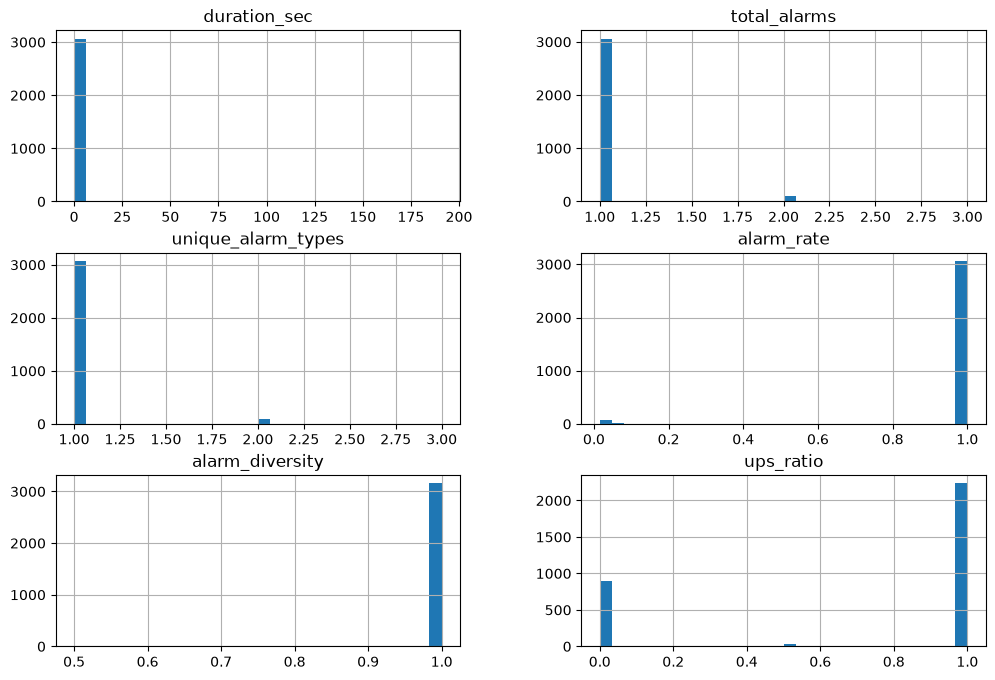

In [48]:
# Distribution of the main features - most are heavily skewed, which is why
# they get standardised before modelling.
features = [
    "duration_sec",
    "total_alarms",
    "unique_alarm_types",
    "alarm_rate",
    "alarm_diversity",
    "ups_ratio",
]

event_features[features].hist(
    figsize=(12,8),
    bins=30
);

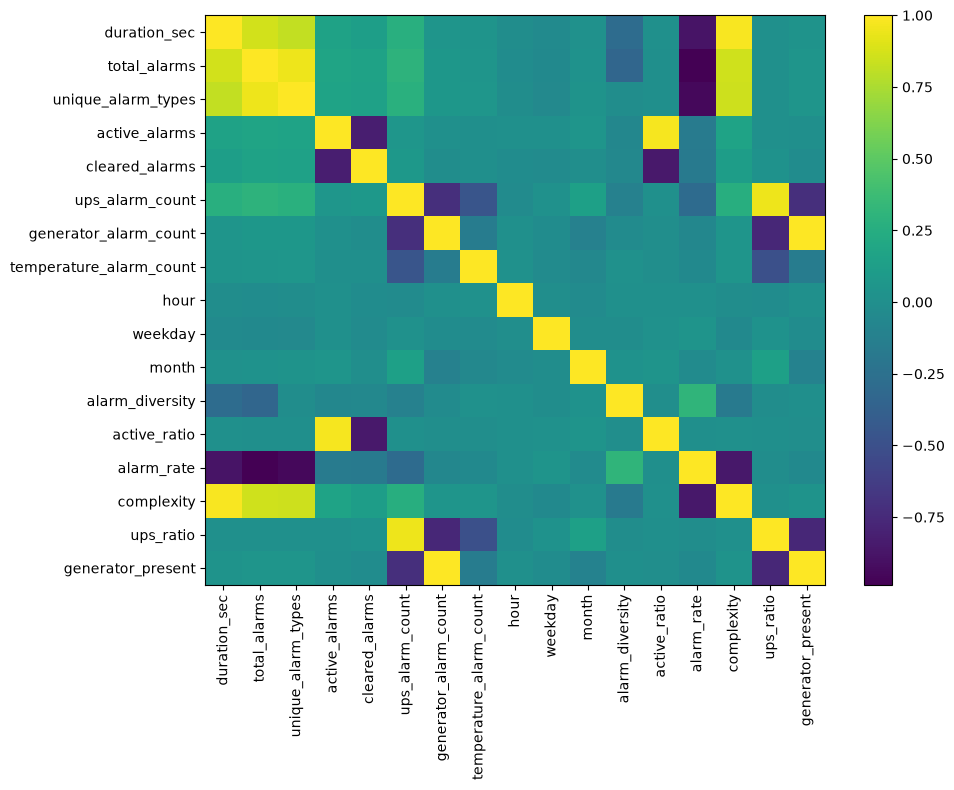

In [49]:
# Correlation heatmap, to spot features that carry the same information.
import matplotlib.pyplot as plt

corr = event_features.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# 11. EVENT-LEVEL ANOMALY DETECTION
# ============================================================
# Two more shape features, then standardise: Isolation Forest and LOF both
# rely on distances, so features must share a common scale.
event_features["repetition_factor"] = (
    event_features["total_alarms"]
    /
    event_features["unique_alarm_types"]
)
event_features["event_intensity"] = (
    event_features["alarm_rate"]
    *
    event_features["unique_alarm_types"]
)
from sklearn.preprocessing import StandardScaler

features = [
    "duration_sec",
    "total_alarms",
    "unique_alarm_types",
    "active_alarms",
    "cleared_alarms",
    "alarm_rate",
    "alarm_diversity",
    "repetition_factor",
    "active_ratio",
    "hour",
]

X = event_features[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
# Isolation Forest on events. contamination=0.03 means we expect about 3% of
# the events to be abnormal.
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,      # about 3% anomalies to start
    random_state=42
)

event_features["anomaly"] = iso.fit_predict(X_scaled)
event_features["score"] = iso.decision_function(X_scaled)

In [52]:
# The 20 most anomalous events (lowest score).
cols = [
    "start_time",
    "duration_sec",
    "total_alarms",
    "unique_alarm_types",
    "alarm_rate",
    "repetition_factor",
    "score"
]

event_features.sort_values("score").head(20)[cols]

,start_time,duration_sec,total_alarms,unique_alarm_types,alarm_rate,repetition_factor,score
event_id,,,,,,,
1674,2026-03-14 10:19:30,191.0,3,2,0.015625,1.5,-0.071612
733,2026-02-10 00:50:58,147.0,3,3,0.020270,1.0,-0.063676
786,2026-02-12 02:35:35,88.0,2,1,0.022472,2.0,-0.057849
2362,2026-04-07 01:58:35,106.0,2,2,0.018692,1.0,-0.053106
678,2026-02-07 05:43:55,114.0,2,1,0.017391,2.0,-0.053064
3012,2026-04-29 00:32:23,97.0,2,2,0.020408,1.0,-0.052937
615,2026-02-04 03:59:37,112.0,2,2,0.017699,1.0,-0.052726
686,2026-02-07 17:35:13,111.0,2,1,0.017857,2.0,-0.052545
1724,2026-03-16 00:52:41,112.0,2,2,0.017699,1.0,-0.052471


In [53]:
# Read the raw alarms of the top 10 anomalies, to judge them by hand.
top_events = event_features.sort_values("score").head(10)

for event in top_events.index:
    print("="*60)
    print(f"Event {event}")
    display(df_events[df_events["event_id"] == event][
        ["log_time", "state", "message"]
    ])

Event 1674


,log_time,state,message
1728,2026-03-14 10:19:30,A,\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK
1729,2026-03-14 10:21:08,A,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY
1730,2026-03-14 10:22:41,A,\BLIDA MSC 10\ UPS BYPASS INPUT SUPPLY NOT OK


Event 733


,log_time,state,message
750,2026-02-10 00:50:58,A,\BLIDA MSC 10\ Salle Switch Temperature Haute
751,2026-02-10 00:52:36,A,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING
752,2026-02-10 00:53:25,A,\BLIDA MSC 10\ UPS GENERAL ALARM


Event 786


...

,log_time,state,message
700,2026-02-07 17:35:13,D,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING
701,2026-02-07 17:37:04,D,\BLIDA MSC 10\ UPS SOCOMEC 1 BATTERY DISCHARGING


Event 1724


,log_time,state,message
1780,2026-03-16 00:52:41,A,\BLIDA MSC 10\ UPS OPERATING ON BATTERY
1781,2026-03-16 00:54:33,A,\BLIDA MSC 10\ UPS RECTIFIER INPUT SUPPLY NOT OK


Event 189


,log_time,state,message
191,2026-01-12 00:09:23,A,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY
192,2026-01-12 00:09:51,D,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY


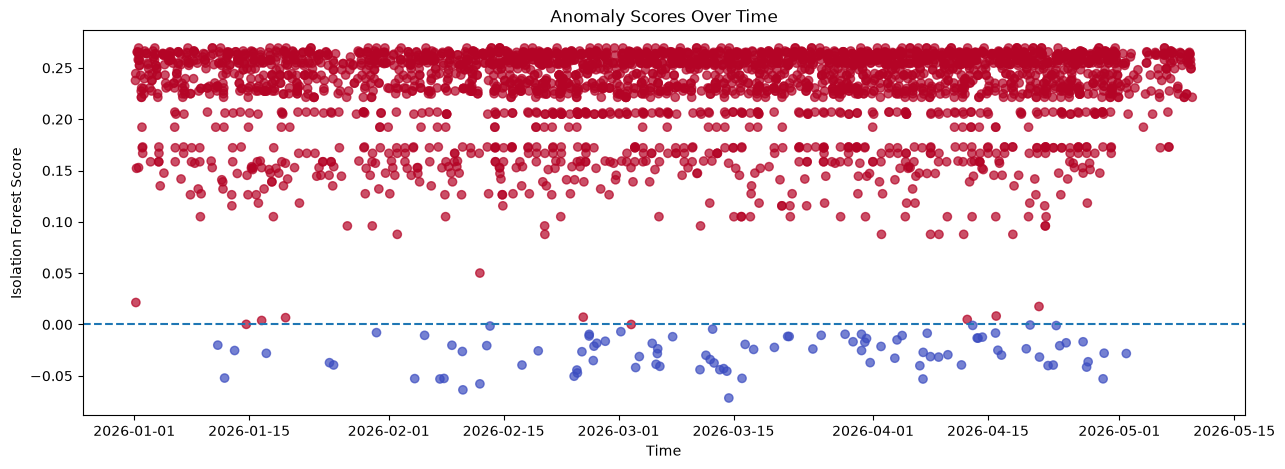

In [54]:
# Anomaly score over time: shows whether abnormal events cluster in periods.
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.scatter(
    event_features["start_time"],
    event_features["score"],
    c=event_features["anomaly"],
    cmap="coolwarm",
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.ylabel("Isolation Forest Score")
plt.xlabel("Time")
plt.title("Anomaly Scores Over Time")

plt.show()

In [55]:
# First attempt at explaining a flag: which feature is in its top 5%.
# (Superseded by the version in cell 67, which precomputes the thresholds.)
def explain_event(event):
    reasons = []

    if event["total_alarms"] > event_features["total_alarms"].quantile(0.95):
        reasons.append("Very high number of alarms")

    if event["duration_sec"] > event_features["duration_sec"].quantile(0.95):
        reasons.append("Long event duration")

    if event["repetition_factor"] > event_features["repetition_factor"].quantile(0.95):
        reasons.append("Repeated alarm cycling")

    if event["unique_alarm_types"] > event_features["unique_alarm_types"].quantile(0.95):
        reasons.append("High alarm diversity")

    return reasons

In [56]:
# Second detector, for comparison. LOF flags points that are in a sparser
# neighbourhood than their neighbours - local rather than global outliers.
# Infinities (from divisions by near-zero durations) are neutralised first.
# LOF training
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

features = [
    "duration_sec", "total_alarms", "unique_alarm_types",
    "active_alarms", "cleared_alarms", "alarm_rate",
    "alarm_diversity", "repetition_factor", "active_ratio", "hour",
]

X = event_features[features].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [57]:
# Fit LOF. negative_outlier_factor_ is the score: the lower, the more isolated.
# n_neighbors cannot exceed the number of events, hence the guard and the min().
if len(event_features) < 3:
    raise ValueError("LOF needs at least 3 events. Increase the data range or reduce event splitting.")

n_neighbors = min(20, len(event_features) - 1)
lof = LocalOutlierFactor(
    n_neighbors=n_neighbors,
    contamination=0.03
)

lof_labels = lof.fit_predict(X_scaled)
event_features['lof_anomaly'] = lof_labels
event_features['lof_score'] = lof.negative_outlier_factor_

print('LOF n_neighbors:', n_neighbors)


LOF n_neighbors: 20


In [58]:
# The 20 events LOF finds most abnormal.

cols = [
    "start_time",
    "duration_sec",
    "total_alarms",
    "unique_alarm_types",
    "alarm_rate",
    "repetition_factor",
    "lof_score"
]

event_features.sort_values("lof_score").head(20)[cols]

,start_time,duration_sec,total_alarms,unique_alarm_types,alarm_rate,repetition_factor,lof_score
event_id,,,,,,,
2251,2026-04-03 15:39:43,36.0,2,1,0.054054,2.0,-4.953054
189,2026-01-12 00:09:23,28.0,2,1,0.068966,2.0,-4.830999
786,2026-02-12 02:35:35,88.0,2,1,0.022472,2.0,-4.804853
1596,2026-03-11 15:25:05,14.0,2,1,0.133333,2.0,-4.621385
2950,2026-04-26 14:02:53,7.0,2,1,0.250000,2.0,-4.542973
1134,2026-02-23 14:02:07,105.0,2,1,0.018868,2.0,-4.542423
454,2026-01-25 06:47:12,71.0,2,1,0.027778,2.0,-4.404907
678,2026-02-07 05:43:55,114.0,2,1,0.017391,2.0,-4.228037
238,2026-01-14 15:32:20,6.0,2,1,0.285714,2.0,-4.218853


In [59]:
# Both scores side by side.
comparison = event_features[
    [
        "score",
        "anomaly",
        "lof_score",
        "lof_anomaly"
    ]
]

comparison.head()

,score,anomaly,lof_score,lof_anomaly
event_id,,,,
0,0.237720,1,-1.000000,1
1,0.244418,1,-1.000000,1
2,0.021423,1,-1.057602,-1
3,0.152154,1,-1.000000,1
4,0.265642,1,-1.000000,1


In [60]:
# How much do the two detectors overlap?
both = event_features[
    (event_features["anomaly"] == -1) &
    (event_features["lof_anomaly"] == -1)
]

print("Isolation Forest anomalies:",
      (event_features["anomaly"] == -1).sum())

print("LOF anomalies:",
      (event_features["lof_anomaly"] == -1).sum())

print("Detected by both:",
      len(both))

Isolation Forest anomalies: 95
LOF anomalies: 95
Detected by both: 57


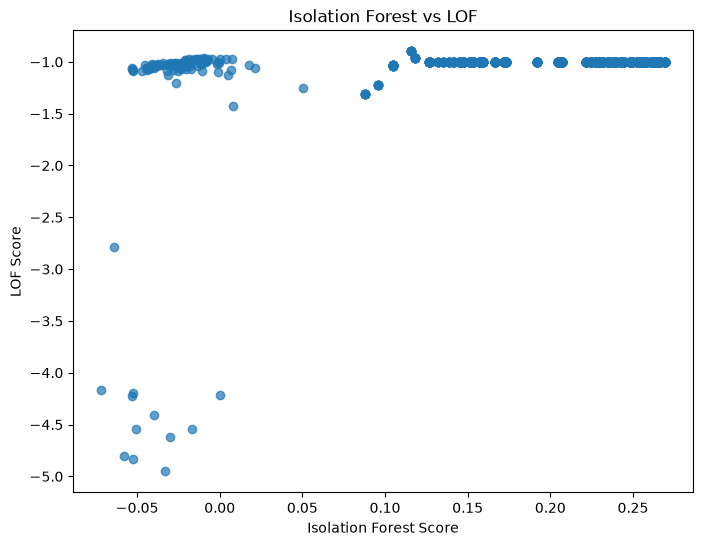

In [61]:
# Scatter of one score against the other - the disagreement is visible here.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    event_features["score"],
    event_features["lof_score"],
    alpha=0.7
)

plt.xlabel("Isolation Forest Score")
plt.ylabel("LOF Score")
plt.title("Isolation Forest vs LOF")

plt.show()

In [62]:
# Consensus: events flagged by both detectors are the most reliable ones.
event_features["consensus_anomaly"] = (
    (event_features["anomaly"] == -1) &
    (event_features["lof_anomaly"] == -1)
)
event_features[
    event_features["consensus_anomaly"]
].sort_values("score")[
    [
        "start_time",
        "duration_sec",
        "total_alarms",
        "unique_alarm_types",
        "score",
        "lof_score"
    ]
]

,start_time,duration_sec,total_alarms,unique_alarm_types,score,lof_score
event_id,,,,,,
1674,2026-03-14 10:19:30,191.0,3,2,-0.071612,-4.166811
733,2026-02-10 00:50:58,147.0,3,3,-0.063676,-2.782224
786,2026-02-12 02:35:35,88.0,2,1,-0.057849,-4.804853
2362,2026-04-07 01:58:35,106.0,2,2,-0.053106,-1.072580
678,2026-02-07 05:43:55,114.0,2,1,-0.053064,-4.228037
3012,2026-04-29 00:32:23,97.0,2,2,-0.052937,-1.061868
615,2026-02-04 03:59:37,112.0,2,2,-0.052726,-1.090422
686,2026-02-07 17:35:13,111.0,2,1,-0.052545,-4.199774
1724,2026-03-16 00:52:41,112.0,2,2,-0.052471,-1.075448


In [63]:
# Same agreement counts, printed again.
print("Isolation Forest anomalies:",
      (event_features["anomaly"] == -1).sum())

print("LOF anomalies:",
      (event_features["lof_anomaly"] == -1).sum())

both = event_features[
    (event_features["anomaly"] == -1) &
    (event_features["lof_anomaly"] == -1)
]

print("Detected by both:", len(both))

Isolation Forest anomalies: 95
LOF anomalies: 95
Detected by both: 57


In [64]:
# Detail of the consensus events.
both.sort_values("score")[[
    "start_time",
    "duration_sec",
    "total_alarms",
    "unique_alarm_types",
    "score",
    "lof_score"
]]

,start_time,duration_sec,total_alarms,unique_alarm_types,score,lof_score
event_id,,,,,,
1674,2026-03-14 10:19:30,191.0,3,2,-0.071612,-4.166811
733,2026-02-10 00:50:58,147.0,3,3,-0.063676,-2.782224
786,2026-02-12 02:35:35,88.0,2,1,-0.057849,-4.804853
2362,2026-04-07 01:58:35,106.0,2,2,-0.053106,-1.072580
678,2026-02-07 05:43:55,114.0,2,1,-0.053064,-4.228037
3012,2026-04-29 00:32:23,97.0,2,2,-0.052937,-1.061868
615,2026-02-04 03:59:37,112.0,2,2,-0.052726,-1.090422
686,2026-02-07 17:35:13,111.0,2,1,-0.052545,-4.199774
1724,2026-03-16 00:52:41,112.0,2,2,-0.052471,-1.075448


In [65]:
# Label every event by who detected it: Both / Isolation Forest only /
# LOF only / Normal.
comparison = event_features.copy()

comparison["IF"] = comparison["anomaly"] == -1
comparison["LOF"] = comparison["lof_anomaly"] == -1

comparison["Detection"] = "Normal"

comparison.loc[
    comparison["IF"] & comparison["LOF"],
    "Detection"
] = "Both"

comparison.loc[
    comparison["IF"] & ~comparison["LOF"],
    "Detection"
] = "Isolation Forest Only"

comparison.loc[
    ~comparison["IF"] & comparison["LOF"],
    "Detection"
] = "LOF Only"

comparison["Detection"].value_counts()

Detection
Normal                   3034
Both                       57
LOF Only                   38
Isolation Forest Only      38
Name: count, dtype: int64

In [66]:
# Events only Isolation Forest flags (typically globally extreme events).
comparison[
    comparison["Detection"] == "Isolation Forest Only"
].sort_values("score")[
    [
        "start_time",
        "total_alarms",
        "duration_sec",
        "unique_alarm_types",
        "score",
        "lof_score"
    ]
]

,start_time,total_alarms,duration_sec,unique_alarm_types,score,lof_score
event_id,,,,,,
1612,2026-03-12 03:44:52,2,43.0,2,-0.034138,-1.011158
1362,2026-03-03 12:40:06,2,74.0,2,-0.031238,-1.022908
2638,2026-04-16 15:26:28,2,54.0,2,-0.029809,-1.006548
2440,2026-04-10 02:44:12,2,37.0,2,-0.029494,-1.020740
3016,2026-04-29 03:33:27,2,98.0,2,-0.027951,-1.009699
1170,2026-02-24 12:50:14,2,52.0,2,-0.026524,-1.006507
2133,2026-03-30 14:22:03,2,36.0,2,-0.025369,-1.017673
1758,2026-03-17 10:46:33,2,38.0,2,-0.024291,-1.015489
1217,2026-02-26 00:09:23,2,58.0,2,-0.021126,-0.977632


In [67]:
# Events only LOF flags (typically locally unusual but not extreme).
comparison[
    comparison["Detection"] == "LOF Only"
].sort_values("lof_score")[
    [
        "start_time",
        "total_alarms",
        "duration_sec",
        "unique_alarm_types",
        "score",
        "lof_score"
    ]
]

,start_time,total_alarms,duration_sec,unique_alarm_types,score,lof_score
event_id,,,,,,
238,2026-01-14 15:32:20,2,6.0,1,0.000147,-4.218853
2622,2026-04-16 00:00:51,2,2.0,2,0.008238,-1.428626
1014,2026-02-20 00:30:37,1,0.0,1,0.087800,-1.313333
575,2026-02-02 00:59:01,1,0.0,1,0.087800,-1.313333
2505,2026-04-12 00:56:25,1,0.0,1,0.087800,-1.313333
2387,2026-04-08 00:02:50,1,0.0,1,0.087800,-1.313333
2206,2026-04-02 00:32:10,1,0.0,1,0.087800,-1.313333
2414,2026-04-09 00:41:58,1,0.0,1,0.087800,-1.313333
2677,2026-04-18 00:42:17,1,0.0,1,0.087800,-1.313333


In [68]:
# ============================================================
# 12. MAKING THE FLAGS EXPLAINABLE
# ============================================================
# Precompute the 95th percentile of each feature once, then describe an event
# in plain language by naming the features that exceed it.
thresholds = {
    "duration": event_features["duration_sec"].quantile(0.95),
    "alarms": event_features["total_alarms"].quantile(0.95),
    "unique": event_features["unique_alarm_types"].quantile(0.95),
    "alarm_rate": event_features["alarm_rate"].quantile(0.95),
    "repetition": event_features["repetition_factor"].quantile(0.95),
}

def explain_event(event, thresholds):

    reasons = []

    if event["duration_sec"] >= thresholds["duration"]:
        reasons.append(
            f"Long event duration ({event['duration_sec']:.0f} sec)"
        )

    if event["total_alarms"] >= thresholds["alarms"]:
        reasons.append(
            f"High alarm count ({event['total_alarms']})"
        )

    if event["unique_alarm_types"] >= thresholds["unique"]:
        reasons.append(
            f"Many unique alarm types ({event['unique_alarm_types']})"
        )

    if event["alarm_rate"] >= thresholds["alarm_rate"]:
        reasons.append(
            f"High alarm rate ({event['alarm_rate']:.2f} alarms/sec)"
        )

    if event["repetition_factor"] >= thresholds["repetition"]:
        reasons.append(
            f"Repeated alarm cycling (factor = {event['repetition_factor']:.2f})"
        )

    if event["generator_alarm_count"] > 0:
        reasons.append("Generator-related alarms detected")

    if event["temperature_alarm_count"] > 0:
        reasons.append("Temperature alarms detected")

    if len(reasons) == 0:
        reasons.append("Detected through unusual feature combination")

    return reasons

In [69]:
# Attach a written explanation to every flagged event.
event_features["Explanation"] = event_features.apply(
    lambda row: "; ".join(explain_event(row, thresholds)),
    axis=1
)
event_features[
    event_features["anomaly"] == -1
][[
    "start_time",
    "score",
    "Explanation"
]].sort_values("score")

,start_time,score,Explanation
event_id,,,
1674,2026-03-14 10:19:30,-0.071612,Long event duration (191 sec); High alarm coun...
733,2026-02-10 00:50:58,-0.063676,Long event duration (147 sec); High alarm coun...
786,2026-02-12 02:35:35,-0.057849,Long event duration (88 sec); High alarm count...
2362,2026-04-07 01:58:35,-0.053106,Long event duration (106 sec); High alarm coun...
678,2026-02-07 05:43:55,-0.053064,Long event duration (114 sec); High alarm coun...
...,...,...,...
1619,2026-03-12 10:58:50,-0.004510,Long event duration (42 sec); High alarm count...
804,2026-02-13 08:12:52,-0.001489,Long event duration (17 sec); High alarm count...
2831,2026-04-23 07:29:59,-0.001031,Long event duration (25 sec); High alarm count...


In [70]:
# Turn the raw score into a severity label for reporting.
# NOTE: severity() is called on the first line but defined just below, so this
# cell only runs on a re-execution - move the def above the .apply() call.
def severity(score):
    if score < -0.10:
        return "Critical"
    elif score < -0.05:
        return "High"
    elif score < -0.02:
        return "Medium"
    return "Low"

event_features['Severity'] = event_features['score'].apply(severity)

report = event_features.loc[
    event_features['anomaly'] == -1,
    ['start_time', 'Severity', 'score', 'Explanation']
].sort_values('score')

print(report)


                  start_time Severity     score  \
event_id                                          
1674     2026-03-14 10:19:30     High -0.071612   
733      2026-02-10 00:50:58     High -0.063676   
786      2026-02-12 02:35:35     High -0.057849   
2362     2026-04-07 01:58:35     High -0.053106   
678      2026-02-07 05:43:55     High -0.053064   
...                      ...      ...       ...   
1619     2026-03-12 10:58:50      Low -0.004510   
804      2026-02-13 08:12:52      Low -0.001489   
2831     2026-04-23 07:29:59      Low -0.001031   
2543     2026-04-13 03:15:27      Low -0.000894   
2735     2026-04-20 03:09:50      Low -0.000512   

                                                Explanation  
event_id                                                     
1674      Long event duration (191 sec); High alarm coun...  
733       Long event duration (147 sec); High alarm coun...  
786       Long event duration (88 sec); High alarm count...  
2362      Long event durat

In [71]:
# ============================================================
# 13. VALIDATION AGAINST MANUALLY CONFIRMED INCIDENTS
# ============================================================
# There is no ground-truth label, so the incidents identified by hand during
# the EDA serve as the reference: each detected event is matched to the
# window it falls into.
known_incidents = [
    ("2026-02-26", "2026-03-01", "CLIM incident + power/generator cascade"),
    ("2026-03-09", "2026-03-16", "Sustained UPS incident (SOCOMEC unit commissioning)"),
    ("2026-04-01", "2026-04-01", "Unconfirmed cluster (possible test/maintenance)"),
    ("2026-04-08", "2026-04-09", "UPS/ENERGY combo incident"),
    ("2026-04-17", "2026-04-17", "11-hour power outage (duration analysis finding)"),
    ("2026-04-25", "2026-04-26", "UPS/ENERGY combo incident"),
    ("2026-05-08", "2026-05-08", "UPS cascade failure"),
]

known_df = pd.DataFrame(known_incidents, columns=['start', 'end', 'description'])
known_df['start'] = pd.to_datetime(known_df['start'])
known_df['end'] = pd.to_datetime(known_df['end']) + pd.Timedelta(hours=23, minutes=59)

def match_known_incident(event_time, known_df):
    for _, row in known_df.iterrows():
        if row['start'] <= event_time <= row['end']:
            return row['description']
    return None

comparison['Known_Incident'] = comparison['start_time'].apply(
    lambda t: match_known_incident(t, known_df)
)
comparison['Known_Incident_Flag'] = comparison['Known_Incident'].notna()

validation_table = comparison[
    (comparison['IF']) | (comparison['LOF']) | (comparison['Known_Incident_Flag'])
][[
    'start_time', 'IF', 'LOF', 'Known_Incident', 'score', 'lof_score'
]].sort_values('start_time')

print(validation_table.to_string())

                  start_time     IF    LOF                                       Known_Incident     score  lof_score
event_id                                                                                                            
2        2026-01-01 04:46:58  False   True                                                  NaN  0.021423  -1.057602
140      2026-01-09 01:26:24  False   True                                                  NaN  0.104991  -1.040000
170      2026-01-11 04:15:26   True  False                                                  NaN -0.020110  -0.981681
189      2026-01-12 00:09:23   True   True                                                  NaN -0.052181  -4.830999
210      2026-01-13 05:27:18   True   True                                                  NaN -0.025352  -1.033943
238      2026-01-14 15:32:20  False   True                                                  NaN  0.000147  -4.218853
291      2026-01-17 02:10:59   True   True                      

In [72]:
# Recall on the known incidents: how many were recovered by at least one of
# the two detectors, and which were missed entirely.
incidents_detected = known_df['description'].isin(
    comparison.loc[comparison['IF'] | comparison['LOF'], 'Known_Incident'].dropna()
)
print(f"Known incidents recovered by at least one model: {incidents_detected.sum()} / {len(known_df)}")
print(known_df[~incidents_detected])  # any incidents completely missed

Known incidents recovered by at least one model: 5 / 7
       start                 end  \
4 2026-04-17 2026-04-17 23:59:00   
6 2026-05-08 2026-05-08 23:59:00   

                                        description  
4  11-hour power outage (duration analysis finding)  
6                               UPS cascade failure  


In [73]:
# ============================================================
# 14. STATE-BASED FEATURES (unresolved alarms per event)
# ============================================================
# Replay the alarm lifecycle inside one event: every A/Q increments the counter
# of that message, every D decrements it. A positive remainder means the alarm
# was never cleared before the event ended.
from collections import defaultdict

def compute_state_features(group):
    group = group.sort_values('log_time')
    active = defaultdict(int)
    q_count = 0

    for _, row in group.iterrows():
        msg = row['message']
        state = row['state']

        if state == 'Q':
            q_count += 1
            active[msg] += 1
        elif state == 'A':
            active[msg] += 1
        elif state == 'D' and active[msg] > 0:
            active[msg] -= 1

    unresolved_count = sum(active.values())
    return pd.Series({
        'q_state_count': q_count,
        'unresolved_count': unresolved_count,
        'state_diversity': group['state'].nunique()
    })


In [74]:
# Apply it to every event and join the result onto the event feature table.
# unresolved_ratio normalises the count by event size, so a long event is not
# penalised just for containing more alarms (clip avoids dividing by zero).
state_features = (
    df_events
    .groupby('event_id', group_keys=False)
    .apply(compute_state_features, include_groups=False)
)

# Join the computed columns to the event-level feature table.
event_features = event_features.join(state_features, how='left')
event_features[['q_state_count', 'unresolved_count', 'state_diversity']] = (
    event_features[['q_state_count', 'unresolved_count', 'state_diversity']]
    .fillna(0)
)

event_features['unresolved_ratio'] = (
    event_features['unresolved_count'] / event_features['total_alarms'].clip(lower=1)
)

print(event_features[['unresolved_count', 'unresolved_ratio']].describe())


       unresolved_count  unresolved_ratio
count       3167.000000       3167.000000
mean           0.542153          0.524945
std            0.520011          0.496045
min            0.000000          0.000000
25%            0.000000          0.000000
50%            1.000000          1.000000
75%            1.000000          1.000000
max            3.000000          1.000000


In [75]:
# Debug: what columns do the two frames carry at this point?
print('df_events columns:')
print(df_events.columns.tolist())
print()
print('event_features columns:')
print(event_features.columns.tolist())


df_events columns:
['log_time', 'state', 'message', 'send_time', 'category', 'date', 'time_since_last', 'is_flap', 'flap_episode', 'gap_seconds', 'event_id']

event_features columns:
['start_time', 'end_time', 'duration_sec', 'total_alarms', 'unique_alarm_types', 'active_alarms', 'cleared_alarms', 'ups_alarm_count', 'generator_alarm_count', 'temperature_alarm_count', 'hour', 'weekday', 'month', 'alarm_diversity', 'active_ratio', 'alarm_rate', 'complexity', 'ups_ratio', 'generator_present', 'repetition_factor', 'event_intensity', 'anomaly', 'score', 'lof_anomaly', 'lof_score', 'consensus_anomaly', 'Explanation', 'Severity', 'q_state_count', 'unresolved_count', 'state_diversity', 'unresolved_ratio']


In [76]:
# ============================================================
# 15. FINAL SIDE-BY-SIDE RUN OF BOTH DETECTORS
# ============================================================
# Same two models on the final feature matrix, both at contamination=0.02
# (~2% of events), stored as 0/1 flags so they can be cross-tabulated.
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso_pred = iso.fit_predict(X)

# -1 anomaly
# 1 normal

event_features["IF"] = (iso_pred==-1).astype(int)

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_pred = lof.fit_predict(X)

event_features["LOF"] = (lof_pred==-1).astype(int)

C:\Users\A\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [77]:
# How many events each detector flags.
comparison = pd.DataFrame({
    "IsolationForest": event_features["IF"].sum(),
    "LOF": event_features["LOF"].sum(),
}, index=["Anomalies"]).T

comparison

,Anomalies
IsolationForest,64
LOF,61


In [78]:
# The events flagged by Isolation Forest, with their explanation and severity.
cols = [
    "start_time",
    "end_time",
    "duration_sec",
    "total_alarms",
    "unique_alarm_types",
    "complexity",
    "event_intensity",
    "repetition_factor",
    "unresolved_ratio",
    "Explanation",
    "Severity"
]

event_features.loc[event_features["IF"] == 1, cols]

,start_time,end_time,duration_sec,total_alarms,unique_alarm_types,complexity,event_intensity,repetition_factor,unresolved_ratio,Explanation,Severity
event_id,,,,,,,,,,,
189,2026-01-12 00:09:23,2026-01-12 00:09:51,28.0,2,1,28.0,0.068966,2.0,0.0,Long event duration (28 sec); High alarm count...,High
445,2026-01-24 18:48:28,2026-01-24 18:49:41,73.0,2,2,146.0,0.054054,1.0,0.0,Long event duration (73 sec); High alarm count...,Medium
454,2026-01-25 06:47:12,2026-01-25 06:48:23,71.0,2,1,71.0,0.027778,2.0,1.0,Long event duration (71 sec); High alarm count...,Medium
615,2026-02-04 03:59:37,2026-02-04 04:01:29,112.0,2,2,224.0,0.035398,1.0,0.0,Long event duration (112 sec); High alarm coun...,High
637,2026-02-05 08:53:19,2026-02-05 08:53:41,22.0,2,2,44.0,0.173913,1.0,0.0,Long event duration (22 sec); High alarm count...,Low
...,...,...,...,...,...,...,...,...,...,...,...
2955,2026-04-27 00:20:00,2026-04-27 00:21:08,68.0,2,2,136.0,0.057971,1.0,1.0,Long event duration (68 sec); High alarm count...,Medium
2962,2026-04-27 04:44:01,2026-04-27 04:45:13,72.0,2,2,144.0,0.054795,1.0,1.0,Long event duration (72 sec); High alarm count...,Medium
3012,2026-04-29 00:32:23,2026-04-29 00:34:00,97.0,2,2,194.0,0.040816,1.0,0.0,Long event duration (97 sec); High alarm count...,High


In [79]:
# Agreement matrix: the (1,1) cell is the set both detectors agree on.
pd.crosstab(event_features["IF"], event_features["LOF"])

LOF,0,1
IF,,
0,3050,53
1,56,8
